# NfL-iPLA Standard Curve: 4PL Fit and Linear Dynamic Range

Produces the standard curve figure for the NfL-iPLA manuscript. Three steps: (1) data loading, (2) four-parameter logistic (4PL) curve fitting, and (3) plot generation showing the 4PL fit overlaid with the empirically determined linear dynamic range.

## 1. Imports

ProxiPal is the custom analysis library for this project — it provides the assay data pipeline, standard curve utilities, and convenience wrappers around scipy. Standard scientific libraries (numpy, pandas, matplotlib, scipy) are also imported explicitly here for clarity.

In [1]:
import sys
from pathlib import Path
from scipy.optimize import curve_fit
from typing import Literal, Dict, Any

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *

OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-05-25 17:13:24
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\NfL-iPLA_standards
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\smith.j\

## 2. Standard Curve Data

`std_curve_data.csv` contains mean Cq values for a serial dilution series of recombinant human NfL (rhNfL). Two dilution series are represented:

- **Filled points** (`type == 'filled'`): the 10-point NfL-iPLA assay standard curve used for routine quantification.
- **Open points** (`type == 'open'`): an extended dilution series characterising the full response envelope, including concentrations above and below the working range.

Concentrations are stored in both linear (`NfL`, pg/mL) and log₁₀-transformed (`log10(NfL)`) form. The response column `e127_50ngml` is the mean Cq from experiment 127 with antibody-oligo conjugate at 50 ng/mL concentration. Note the inverse signal direction relative to a conventional ELISA: Cq *decreases* as NfL concentration *increases*, because higher target abundance drives more efficient proximity ligation and earlier PCR amplification.

In [2]:
std_curve_df = pd.read_csv('std_curve_data.csv')
std_curve_df


,NfL,log10(NfL),e127_25ngml,e127_50ngml,type
0,500000.000,5.69897,11.808775,9.986743,open
1,50000.000,4.69897,10.954835,9.833784,open
2,10000.000,4.00000,NaN,12.173447,open
3,5000.000,3.69897,13.777852,13.011159,open
4,2000.000,3.30103,NaN,14.488466,filled
5,500.000,2.69897,17.387409,16.464000,open
6,400.000,2.60206,NaN,16.903264,filled
7,80.000,1.90309,NaN,19.422435,filled
8,50.000,1.69897,20.845915,19.828148,open
9,16.000,1.20412,NaN,21.739659,filled


## 3. Four-Parameter Logistic (4PL) Curve Fitting

We can use scipy's 4PL fit for this purpose because the function is able to pick parameters A,B,C,D from the extended standard curve (it has visible lower and upper inflection points)

In [3]:
def _xlog10_4pl(x, A, B, C, D):
    """4PL model parameterised in log10(concentration) space."""
    return A + (D - A) / (1.0 + np.exp(-B * (x - C)))


def fit_4pl_df(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    transform_x: Literal["linear(x)", "log10(x)"] = "log10(x)",
    plot: bool = False
) -> Dict[str, Any]:
    """
    Fit a 4PL model to a standard curve dataframe.

    Parameters
    ----------
    df           : DataFrame with x and y columns
    x_col        : Column containing x values (log10 concentration if transform_x='log10(x)')
    y_col        : Column containing response values (Cq)
    transform_x  : Use 'log10(x)' for the log-space sigmoid form
    plot         : If True, show a quick diagnostic scatter + fit plot

    Returns
    -------
    dict : {params, cov, r2, ec50, predict_fn, transform_x, success_method}
    """
    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    if x.size < 4:
        raise ValueError("Not enough valid points for 4PL fit (need >=4).")

    # TRF is more robust to poor initialisations; fall back to LM if it fails
    try:
        popt, pcov = curve_fit(_xlog10_4pl, x, y, maxfev=10000, method="trf")
        method = "trf"
    except Exception:
        popt, pcov = curve_fit(_xlog10_4pl, x, y, maxfev=10000, method="lm")
        method = "lm"

    A, B, C, D = popt
    y_hat  = _xlog10_4pl(x, *popt)
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2     = 1.0 - ss_res / ss_tot

    predict_fn = lambda x_new: _xlog10_4pl(x_new, *popt)

    if plot:
        xs = np.linspace(x.min(), x.max(), 400)
        plt.figure(figsize=(7, 4))
        plt.scatter(x, y, color="black", zorder=5, label="Data")
        plt.plot(xs, predict_fn(xs), "b--", label=f"4PL fit (R²={r2:.4f})")
        plt.xlabel(x_col); plt.ylabel(y_col)
        plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout(); plt.show()

    return {
        "params": tuple(popt),
        "cov": pcov,
        "r2": r2,
        "ec50": C,
        "predict_fn": predict_fn,
        "transform_x": transform_x,
        "success_method": method
    }


### Run the fit

Fit the 4PL to all calibrator points (both filled and open) using log₁₀-transformed concentration as x. The `predict_fn` returned here is used to render the smooth fitted curve below. R² ≥ 0.999 is expected for a well-behaved immunoassay standard curve.

In [4]:
res_log = fit_4pl_df(std_curve_df,
                     x_col='log10(NfL)', y_col='e127_50ngml',
                     transform_x='log10(x)', plot=False)

print(f'4PL parameters (A, B, C, D): {tuple(round(p, 4) for p in res_log["params"])}')
print(f'R²:                          {res_log["r2"]:.4f}')
print(f'EC50 (log₁₀ pg/mL):           {res_log["ec50"]:.4f}  ({10**res_log["ec50"]:.1f} pg/mL)')


4PL parameters (A, B, C, D): (np.float64(32.5119), np.float64(0.6261), np.float64(1.7032), np.float64(7.4863))
R²:                          0.9973
EC50 (log₁₀ pg/mL):           1.7032  (50.5 pg/mL)


## 4. Standard Curve Plot

The final figure overlays three elements:

1. **Calibrator data points**: filled circles = routine 10-point assay standard curve; open circles = extended dilution series used to map the full response envelope.
2. **4PL fit** (dotted line): smooth curve across the full concentration range, showing the upper and lower Cq asymptotes flanking the linear working range.
3. **Linear dynamic range segment** (red line): straight-line fit through the empirically determined linear range endpoints (0.128 to 50,000 pg/mL). The slope and intercept are shown in the legend. This is the range within which back-calculation from Cq to concentration is reliable.

The **Cq span** annotation (18.9 cycles across 5.7 log₁₀ units) quantifies the linear dynamic range. This is an exceptionally wide dynamic range for a plasma immunoassay, and is a key performance claim of the NfL-iPLA. It reflects near-ideal PCR amplification efficiency of the proximity ligation product combined with the absence of hook-effect compression within this range.

The x-axis is displayed in linear concentration (pg/mL) for interpretability, but the underlying fit and all statistics are in log₁₀ space.

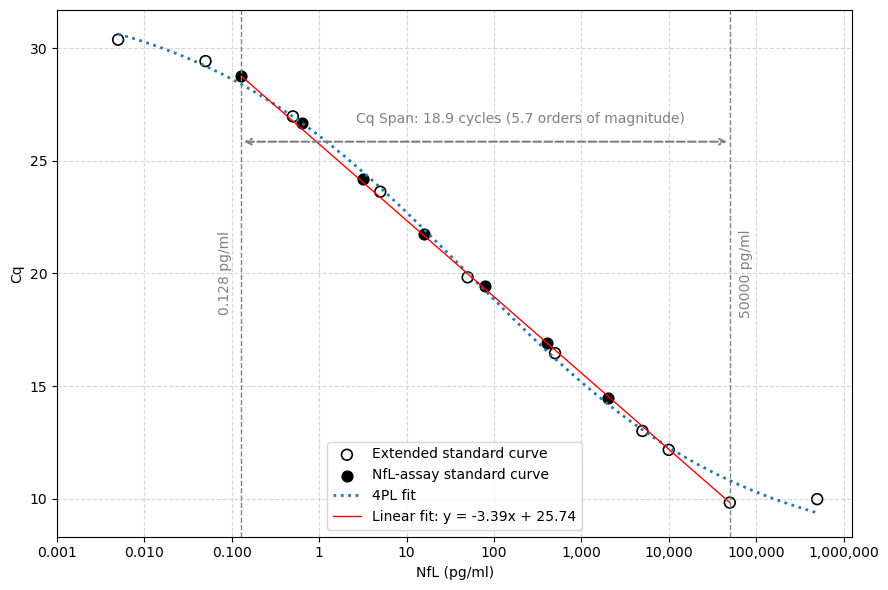

In [5]:
import numpy as np
import matplotlib.pyplot as plt

predict_4pl = res_log['predict_fn']

# Smooth 4PL curve across the full concentration range in log10 space
x_min = std_curve_df['log10(NfL)'].min()
x_max = std_curve_df['log10(NfL)'].max()
xs      = np.linspace(x_min, x_max, 600)
ys_4pl  = predict_4pl(xs)

# Linear dynamic range endpoints (empirically determined)
x_start, y_start = -0.89279003, 28.762166   # 0.128 pg/mL
x_end,   y_end   =  4.698970004, 9.833784   # 50,000 pg/mL

# Slope and intercept of the linear segment (shown in legend)
slope     = (y_end - y_start) / (x_end - x_start)
intercept = y_start - slope * x_start
linear_eq = f'Linear fit: y = {slope:.2f}x + {intercept:.2f}'

fig, ax = plt.subplots(figsize=(9, 6))

# Separate marker styles for extended vs assay standard curve
open_points   = std_curve_df[std_curve_df['type'] == 'open']
filled_points = std_curve_df[std_curve_df['type'] == 'filled']

ax.scatter(open_points['log10(NfL)'], open_points['e127_50ngml'],
           facecolors='none', edgecolors='black', s=60, linewidth=1.2,
           label='Extended standard curve')
ax.scatter(filled_points['log10(NfL)'], filled_points['e127_50ngml'],
           color='black', s=60,
           label='NfL-assay standard curve')

# 4PL smooth fit
ax.plot(xs, ys_4pl, linestyle=':', linewidth=2, label='4PL fit')

# Linear dynamic range segment with equation in legend
ax.plot([x_start, x_end], [y_start, y_end],
        color='red', linewidth=1, label=linear_eq)

# Vertical boundary markers
ax.axvline(x=x_start, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=x_end,   color='gray', linestyle='--', linewidth=1)

# Cq span annotation
y_min, y_max = ax.get_ylim()
y_mid  = 0.5 * (y_min + y_max)
y_span = y_min + 0.75 * (y_max - y_min)

ax.annotate('', xy=(x_end, y_span), xytext=(x_start, y_span),
            arrowprops=dict(arrowstyle='<->', linestyle='--', linewidth=1.5, color='gray'))
ax.text(0.5 * (x_start + x_end), y_span + 0.03 * (y_max - y_min),
        '                Cq Span: 18.9 cycles (5.7 orders of magnitude)',
        ha='center', va='bottom', fontsize=10, color='gray')

# Concentration labels at boundary lines
ax.text(x_start, y_mid, '0.128 pg/ml\n\n', rotation=90,
        ha='center', va='center', fontsize=10, color='gray')
ax.text(x_end,   y_mid, '\n\n50000 pg/ml', rotation=90,
        ha='center', va='center', fontsize=10, color='gray')

# X-axis: linear concentration labels on log10 axis positions
tick_values = np.array([0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000])
log_ticks   = np.log10(tick_values)
ax.set_xticks(log_ticks)
ax.set_xticklabels([f'{int(v):,}' if v >= 1 else f'{v:.3f}' for v in tick_values])

ax.set_xlabel('NfL (pg/ml)')
ax.set_ylabel('Cq')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
fig.tight_layout()
# plt.savefig('nfl_std_curve_4PLvLin.svg', dpi=300, bbox_inches='tight')
plt.show()


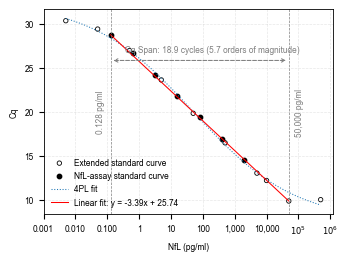

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

# ── Apply publication rcParams ─────────────────────────────────────────────
plt.rcParams['font.family']        = 'sans-serif'
plt.rcParams['font.sans-serif']    = ['Helvetica', 'Arial']
plt.rcParams['font.size']          = 6
plt.rcParams['axes.titlesize']     = 6
plt.rcParams['axes.labelsize']     = 6
plt.rcParams['xtick.labelsize']    = 6
plt.rcParams['ytick.labelsize']    = 6
plt.rcParams['legend.fontsize']    = 6
plt.rcParams['scatter.edgecolors'] = 'none'
plt.rcParams['axes.linewidth']     = 0.6

predict_4pl = res_log['predict_fn']

# Smooth 4PL curve across the full concentration range in log10 space
x_min = std_curve_df['log10(NfL)'].min()
x_max = std_curve_df['log10(NfL)'].max()
xs     = np.linspace(x_min, x_max, 600)
ys_4pl = predict_4pl(xs)

# Linear dynamic range endpoints (empirically determined)
x_start, y_start = -0.89279003,   28.762166   # 0.128 pg/mL
x_end,   y_end   =  4.698970004,   9.833784   # 50,000 pg/mL

# Slope and intercept of the linear segment
slope     = (y_end - y_start) / (x_end - x_start)
intercept = y_start - slope * x_start
linear_eq = f'Linear fit: y = {slope:.2f}x + {intercept:.2f}'

# ── Figure: 88 mm × 66 mm single-column ───────────────────────────────────
fig, ax = plt.subplots(figsize=(88/25.4, 66/25.4))

# Separate marker styles for extended vs assay standard curve
open_points   = std_curve_df[std_curve_df['type'] == 'open']
filled_points = std_curve_df[std_curve_df['type'] == 'filled']

ax.scatter(open_points['log10(NfL)'],   open_points['e127_50ngml'],
           facecolors='none', edgecolors='black', s=10, linewidth=0.6,
           label='Extended standard curve')
ax.scatter(filled_points['log10(NfL)'], filled_points['e127_50ngml'],
           color='black', s=10,
           label='NfL-assay standard curve')

# 4PL smooth fit
ax.plot(xs, ys_4pl, linestyle=':', linewidth=0.75, label='4PL fit')

# Linear dynamic range segment
ax.plot([x_start, x_end], [y_start, y_end],
        color='red', linewidth=0.75, label=linear_eq)

# Vertical boundary markers
ax.axvline(x=x_start, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=x_end,   color='gray', linestyle='--', linewidth=0.5)

# Cq span annotation
y_min, y_max = ax.get_ylim()
y_mid  = 0.5 * (y_min + y_max)
y_span = y_min + 0.75 * (y_max - y_min)

ax.annotate('', xy=(x_end, y_span), xytext=(x_start, y_span),
            arrowprops=dict(arrowstyle='<->', linestyle='--',
                            linewidth=0.75, color='gray'))
ax.text(0.6 * (x_start + x_end), y_span + 0.03 * (y_max - y_min),
        'Cq Span: 18.9 cycles (5.7 orders of magnitude)',
        ha='center', va='bottom', fontsize=6, color='gray')

# Concentration labels at boundary lines
ax.text(x_start, y_mid, '0.128 pg/ml\n\n', rotation=90,
        ha='center', va='center', fontsize=6, color='gray')
ax.text(x_end,   y_mid, '\n\n50,000 pg/ml', rotation=90,
        ha='center', va='center', fontsize=6, color='gray')

# X-axis: mixed decimal / scientific notation labels
def fmt_conc(v):
    if v < 1:
        return f'{v:.3f}'
    elif v < 1e5:
        return f'{int(v):,}'
    else:
        exp = int(np.log10(v))
        return f'$10^{{{exp}}}$'

tick_values = np.array([0.001, 0.01, 0.1, 1, 10, 100, 1000, 1e4, 1e5, 1e6])
log_ticks   = np.log10(tick_values)
ax.set_xticks(log_ticks)
ax.set_xticklabels([fmt_conc(v) for v in tick_values])

ax.set_xlabel('NfL (pg/ml)')
ax.set_ylabel('Cq')
ax.grid(True, which='major', linestyle='--', alpha=0.3, linewidth=0.5)
ax.legend(frameon=False)

fig.tight_layout()
# plt.savefig('nfl_std_curve_4PLvLin.svg', dpi=300, bbox_inches='tight')
plt.show()

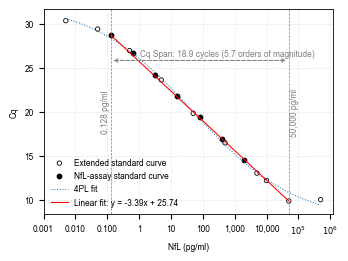

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

# ── Apply publication rcParams ─────────────────────────────────────────────
plt.rcParams['font.family']        = 'sans-serif'
plt.rcParams['font.sans-serif']    = ['Helvetica', 'Arial']
plt.rcParams['font.size']          = 6
plt.rcParams['axes.titlesize']     = 6
plt.rcParams['axes.labelsize']     = 6
plt.rcParams['xtick.labelsize']    = 6
plt.rcParams['ytick.labelsize']    = 6
plt.rcParams['legend.fontsize']    = 6
plt.rcParams['scatter.edgecolors'] = 'none'
plt.rcParams['axes.linewidth']     = 0.6

predict_4pl = res_log['predict_fn']

# Smooth 4PL curve across the full concentration range in log10 space
x_min = std_curve_df['log10(NfL)'].min()
x_max = std_curve_df['log10(NfL)'].max()
xs     = np.linspace(x_min, x_max, 600)
ys_4pl = predict_4pl(xs)

# Linear dynamic range endpoints (empirically determined)
x_start, y_start = -0.89279003,  28.762166   # 0.128 pg/mL
x_end,   y_end   =  4.698970004,  9.833784   # 50,000 pg/mL

# Slope and intercept of the linear segment
slope     = (y_end - y_start) / (x_end - x_start)
intercept = y_start - slope * x_start
linear_eq = f'Linear fit: y = {slope:.2f}x + {intercept:.2f}'

# ── Figure: 88 mm × 66 mm single-column ───────────────────────────────────
fig, ax = plt.subplots(figsize=(88/25.4, 66/25.4))

# Separate marker styles for extended vs assay standard curve
open_points   = std_curve_df[std_curve_df['type'] == 'open']
filled_points = std_curve_df[std_curve_df['type'] == 'filled']

ax.scatter(open_points['log10(NfL)'],   open_points['e127_50ngml'],
           facecolors='none', edgecolors='black', s=10, linewidth=0.6,
           label='Extended standard curve')
ax.scatter(filled_points['log10(NfL)'], filled_points['e127_50ngml'],
           color='black', s=10,
           label='NfL-assay standard curve')

# 4PL smooth fit
ax.plot(xs, ys_4pl, linestyle=':', linewidth=0.75, label='4PL fit')

# Linear dynamic range segment
ax.plot([x_start, x_end], [y_start, y_end],
        color='red', linewidth=0.75, label=linear_eq)

# Vertical boundary markers
ax.axvline(x=x_start, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=x_end,   color='gray', linestyle='--', linewidth=0.5)

# Cq span annotation
y_min, y_max = ax.get_ylim()
y_mid  = 0.5 * (y_min + y_max)
y_span = y_min + 0.75 * (y_max - y_min)

ax.annotate('', xy=(x_end, y_span), xytext=(x_start, y_span),
            arrowprops=dict(arrowstyle='<->', linestyle='--',
                            linewidth=0.75, color='gray'))
ax.text(0.73 * (x_start + x_end), y_span + 0.01 * (y_max - y_min),
        'Cq Span: 18.9 cycles (5.7 orders of magnitude)',
        ha='center', va='bottom', fontsize=6, color='gray')

# Concentration labels at boundary lines
ax.text(x_start-0.032, y_mid, '0.128 pg/ml', rotation=90,
        ha='right', va='center', fontsize=6, color='gray')
ax.text(x_end + 0.05,   y_mid, '50,000 pg/ml', rotation=90,
        ha='left', va='center', fontsize=6, color='gray')

# X-axis: mixed decimal / scientific notation labels
def fmt_conc(v):
    if v < 1:
        return f'{v:.3f}'
    elif v < 1e5:
        return f'{int(v):,}'
    else:
        exp = int(np.log10(v))
        return f'$10^{{{exp}}}$'

tick_values = np.array([0.001, 0.01, 0.1, 1, 10, 100, 1000, 1e4, 1e5, 1e6])
log_ticks   = np.log10(tick_values)
ax.set_xticks(log_ticks)
ax.set_xticklabels([fmt_conc(v) for v in tick_values])

ax.set_xlabel('NfL (pg/ml)')
ax.set_ylabel('Cq')
ax.grid(True, which='major', linestyle='--', alpha=0.3, linewidth=0.5)
ax.legend(frameon=False)

fig.tight_layout()
plt.savefig('nfl_std_curve_4PLvLin.svg', dpi=300, bbox_inches='tight')
plt.show()